In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kimjmin/seoul-metro-usage/seoul-metro-2020.logs.csv
/kaggle/input/datasets/kimjmin/seoul-metro-usage/seoul-metro-2021.logs.csv
/kaggle/input/datasets/kimjmin/seoul-metro-usage/seoul-metro-station-info.csv
/kaggle/input/datasets/kimjmin/seoul-metro-usage/seoul-metro-2017.logs.csv
/kaggle/input/datasets/kimjmin/seoul-metro-usage/seoul-metro-2016.logs.csv
/kaggle/input/datasets/kimjmin/seoul-metro-usage/seoul-metro-2019.logs.csv
/kaggle/input/datasets/kimjmin/seoul-metro-usage/seoul-metro-2018.logs.csv
/kaggle/input/datasets/kimjmin/seoul-metro-usage/seoul-metro-2015.logs.csv


In [3]:
# ============================================================
# MetroFlow — Data Cleaning (Week 1)
# Cleans station info + 2015/2016/2017 ridership logs
# Outputs a clean, merged dataset ready for modeling later
# ============================================================

import pandas as pd
import numpy as np

# ---------------- 1. LOAD ----------------
STATION_PATH = "/kaggle/input/datasets/kimjmin/seoul-metro-usage/seoul-metro-station-info.csv"
LOG_FILES = [
    "/kaggle/input/datasets/kimjmin/seoul-metro-usage/seoul-metro-2015.logs.csv",
    "/kaggle/input/datasets/kimjmin/seoul-metro-usage/seoul-metro-2016.logs.csv",
    "/kaggle/input/datasets/kimjmin/seoul-metro-usage/seoul-metro-2017.logs.csv",
]

stations = pd.read_csv(STATION_PATH, encoding="utf-8-sig")
logs = pd.concat([pd.read_csv(f) for f in LOG_FILES], ignore_index=True)
print("Raw logs shape:", logs.shape)
print("Raw stations shape:", stations.shape)

# ---------------- 2. CLEAN STATION INFO ----------------
# Known source-data bug: these 4 stations have English names shifted
# one row off from the correct Korean name / station_code
NAME_EN_CORRECTIONS = {
    158: "Cheongnyangni", 157: "Jegidong",
    156: "Sinseoldong",   159: "Dongmyo",
}

keep_cols = {
    "station.code": "station_code", "line.num": "line_num",
    "line.name": "line_name", "line.station_seq": "line_seq",
    "station.name": "station_name_kr", "station.name_en": "station_name_en",
    "geo.latitude": "latitude", "geo.longitude": "longitude",
    "geo.sigungu_name": "district", "geo.addres_road": "address",
    "geo.phone": "phone",
}
stations = stations[list(keep_cols.keys())].rename(columns=keep_cols)

for code, name in NAME_EN_CORRECTIONS.items():
    stations.loc[stations["station_code"] == code, "station_name_en"] = name

for c in stations.select_dtypes(include="object").columns:
    stations[c] = stations[c].astype(str).str.strip()

stations["station_name_kr"] = stations["station_name_kr"].str.split("|").str[0]
stations = stations.drop_duplicates(subset=["station_code"])

stations["latitude"] = pd.to_numeric(stations["latitude"], errors="coerce")
stations["longitude"] = pd.to_numeric(stations["longitude"], errors="coerce")
stations = stations.dropna(subset=["latitude", "longitude"])

print("Clean stations shape:", stations.shape)

# ---------------- 3. CLEAN RIDERSHIP LOGS ----------------
logs["timestamp"] = pd.to_datetime(logs["timestamp"], utc=True).dt.tz_convert("Asia/Seoul")

# drop rows with missing critical fields
logs = logs.dropna(subset=["station_code", "timestamp", "people_in", "people_out"])

# drop negative/invalid counts
logs = logs[(logs["people_in"] >= 0) & (logs["people_out"] >= 0)]

# drop exact duplicate rows (same station + same timestamp)
before = len(logs)
logs = logs.drop_duplicates(subset=["station_code", "timestamp"])
print(f"Dropped {before - len(logs)} duplicate log rows")

# cap extreme outliers (top 0.1% of total flow) — likely sensor errors
logs["total_flow"] = logs["people_in"] + logs["people_out"]
cap = logs["total_flow"].quantile(0.999)
before = len(logs)
logs = logs[logs["total_flow"] <= cap]
print(f"Dropped {before - len(logs)} outlier rows above {cap:.0f} total flow")

# drop log rows whose station_code has no match in the station table
before = len(logs)
logs = logs[logs["station_code"].isin(stations["station_code"])]
print(f"Dropped {before - len(logs)} rows with unmatched station_code")

print("Clean logs shape:", logs.shape)

# ---------------- 4. MERGE ----------------
df = logs.merge(stations, on="station_code", how="inner")
print("Merged clean dataset shape:", df.shape)

# ---------------- 5. SAVE ----------------
stations.to_csv("/kaggle/working/seoul_metro_stations_clean.csv", index=False)
logs.to_csv("/kaggle/working/seoul_metro_logs_2015_2017_clean.csv", index=False)
df.to_csv("/kaggle/working/seoul_metro_merged_clean.csv", index=False)

print("\nSaved:")
print("- seoul_metro_stations_clean.csv")
print("- seoul_metro_logs_2015_2017_clean.csv")
print("- seoul_metro_merged_clean.csv")

print("\nPreview of merged clean data:")
print(df.head())

Raw logs shape: (6028000, 4)
Raw stations shape: (285, 19)
Clean stations shape: (285, 11)
Dropped 0 duplicate log rows
Dropped 6027 outlier rows above 17822 total flow
Dropped 0 rows with unmatched station_code
Clean logs shape: (6021973, 5)
Merged clean dataset shape: (6021973, 15)

Saved:
- seoul_metro_stations_clean.csv
- seoul_metro_logs_2015_2017_clean.csv
- seoul_metro_merged_clean.csv

Preview of merged clean data:
                  timestamp  station_code  people_in  people_out  total_flow  \
0 2015-01-01 05:00:00+09:00           150        441         392         833   
1 2015-01-01 06:00:00+09:00           150        399        1396        1795   
2 2015-01-01 07:00:00+09:00           150        572        1391        1963   
3 2015-01-01 08:00:00+09:00           150       1106        1913        3019   
4 2015-01-01 09:00:00+09:00           150       1474        2351        3825   

   line_num line_name  line_seq station_name_kr station_name_en   latitude  \
0         1   

In [4]:
df.head(10)

,timestamp,station_code,people_in,people_out,total_flow,line_num,line_name,line_seq,station_name_kr,station_name_en,latitude,longitude,district,address,phone
0,2015-01-01 05:00:00+09:00,150,441,392,833,1,1호선,10,서울역,Seoul Station,37.554648,126.972559,중구,서울특별시 중구 세종대로 지하2(남대문로 5가),02-6110-1331
1,2015-01-01 06:00:00+09:00,150,399,1396,1795,1,1호선,10,서울역,Seoul Station,37.554648,126.972559,중구,서울특별시 중구 세종대로 지하2(남대문로 5가),02-6110-1331
2,2015-01-01 07:00:00+09:00,150,572,1391,1963,1,1호선,10,서울역,Seoul Station,37.554648,126.972559,중구,서울특별시 중구 세종대로 지하2(남대문로 5가),02-6110-1331
3,2015-01-01 08:00:00+09:00,150,1106,1913,3019,1,1호선,10,서울역,Seoul Station,37.554648,126.972559,중구,서울특별시 중구 세종대로 지하2(남대문로 5가),02-6110-1331
4,2015-01-01 09:00:00+09:00,150,1474,2351,3825,1,1호선,10,서울역,Seoul Station,37.554648,126.972559,중구,서울특별시 중구 세종대로 지하2(남대문로 5가),02-6110-1331
5,2015-01-01 10:00:00+09:00,150,2020,2319,4339,1,1호선,10,서울역,Seoul Station,37.554648,126.972559,중구,서울특별시 중구 세종대로 지하2(남대문로 5가),02-6110-1331
6,2015-01-01 11:00:00+09:00,150,2769,2496,5265,1,1호선,10,서울역,Seoul Station,37.554648,126.972559,중구,서울특별시 중구 세종대로 지하2(남대문로 5가),02-6110-1331
7,2015-01-01 12:00:00+09:00,150,3531,2717,6248,1,1호선,10,서울역,Seoul Station,37.554648,126.972559,중구,서울특별시 중구 세종대로 지하2(남대문로 5가),02-6110-1331
8,2015-01-01 13:00:00+09:00,150,3481,2964,6445,1,1호선,10,서울역,Seoul Station,37.554648,126.972559,중구,서울특별시 중구 세종대로 지하2(남대문로 5가),02-6110-1331
9,2015-01-01 14:00:00+09:00,150,2858,2680,5538,1,1호선,10,서울역,Seoul Station,37.554648,126.972559,중구,서울특별시 중구 세종대로 지하2(남대문로 5가),02-6110-1331


In [5]:
df.shape

(6021973, 15)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

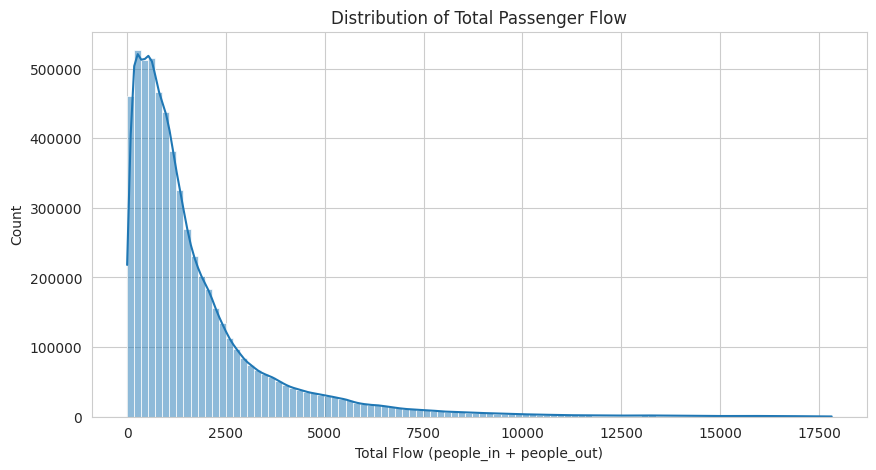

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(df["total_flow"], bins=100, kde=True)
plt.title("Distribution of Total Passenger Flow")
plt.xlabel("Total Flow (people_in + people_out)")
plt.show()

In [8]:
# Check what columns you actually have
print(df.columns.tolist())

['timestamp', 'station_code', 'people_in', 'people_out', 'total_flow', 'line_num', 'line_name', 'line_seq', 'station_name_kr', 'station_name_en', 'latitude', 'longitude', 'district', 'address', 'phone']


In [9]:
# Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Create time-based features
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek       # 0=Mon .. 6=Sun
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["month"] = df["timestamp"].dt.month
df["is_morning_peak"] = df["hour"].between(7, 9).astype(int)
df["is_evening_peak"] = df["hour"].between(18, 20).astype(int)
df["year"] = df["timestamp"].dt.year

print(df.columns.tolist())

['timestamp', 'station_code', 'people_in', 'people_out', 'total_flow', 'line_num', 'line_name', 'line_seq', 'station_name_kr', 'station_name_en', 'latitude', 'longitude', 'district', 'address', 'phone', 'hour', 'day_of_week', 'is_weekend', 'month', 'is_morning_peak', 'is_evening_peak', 'year']


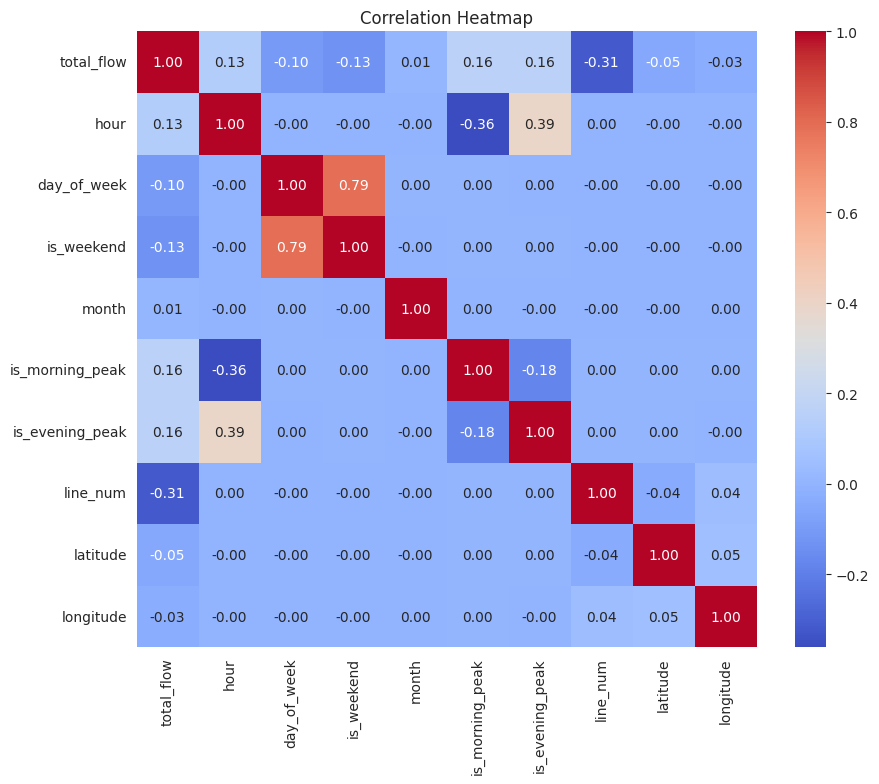

In [10]:
numeric_cols = ["total_flow", "hour", "day_of_week", "is_weekend", "month",
                 "is_morning_peak", "is_evening_peak", "line_num", "latitude", "longitude"]

plt.figure(figsize=(10,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

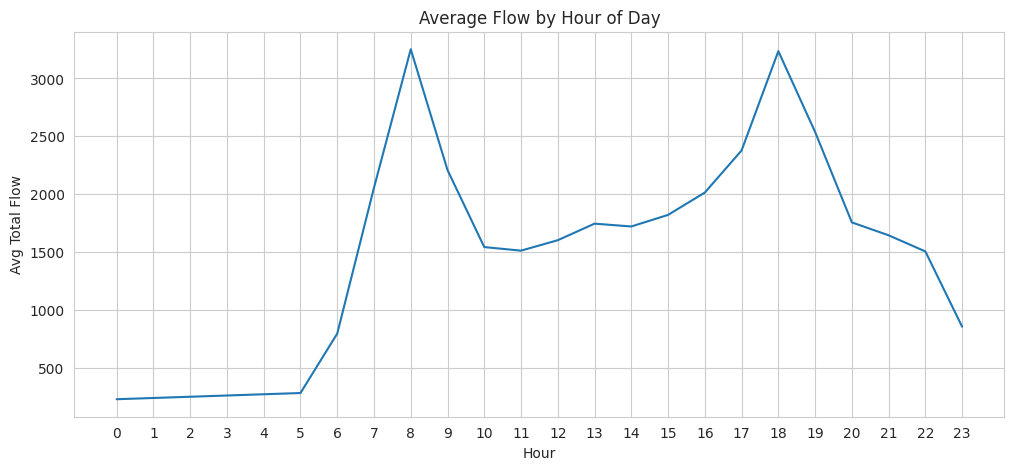

In [11]:
plt.figure(figsize=(12,5))
sns.lineplot(data=df, x="hour", y="total_flow", estimator="mean", errorbar=None)
plt.title("Average Flow by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Avg Total Flow")
plt.xticks(range(0,24))
plt.show()

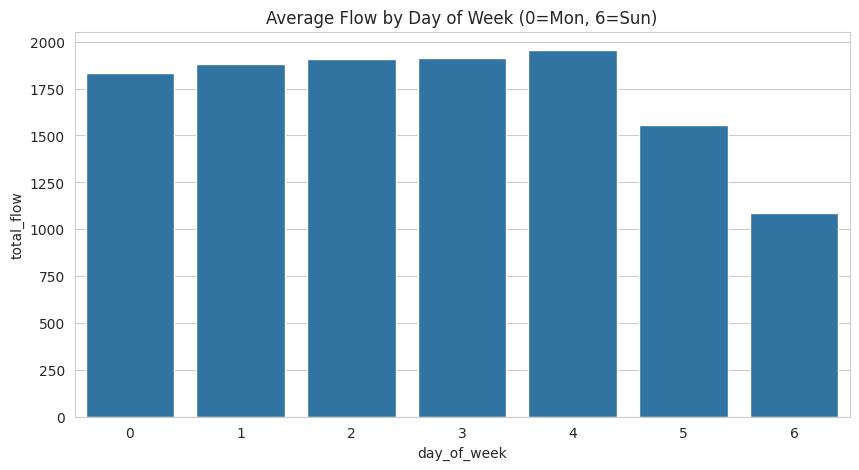

In [12]:
day_avg = df.groupby("day_of_week")["total_flow"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=day_avg, x="day_of_week", y="total_flow")
plt.title("Average Flow by Day of Week (0=Mon, 6=Sun)")
plt.show()

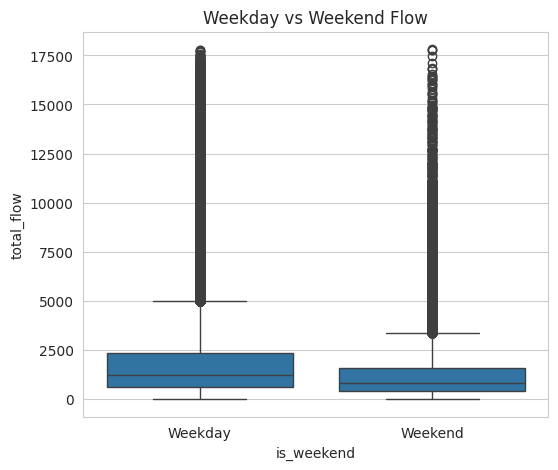

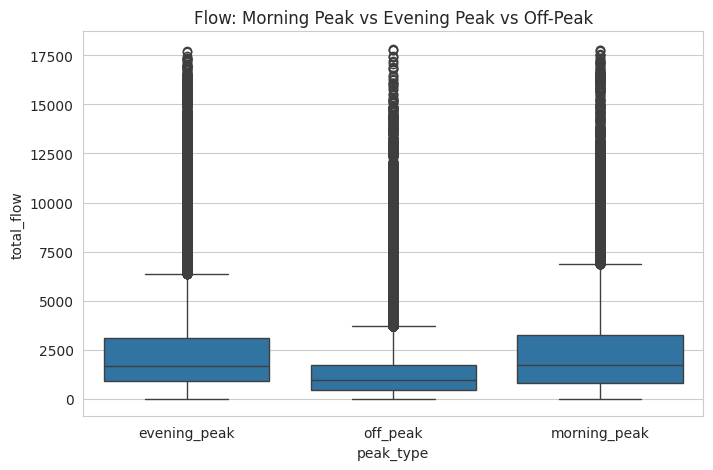

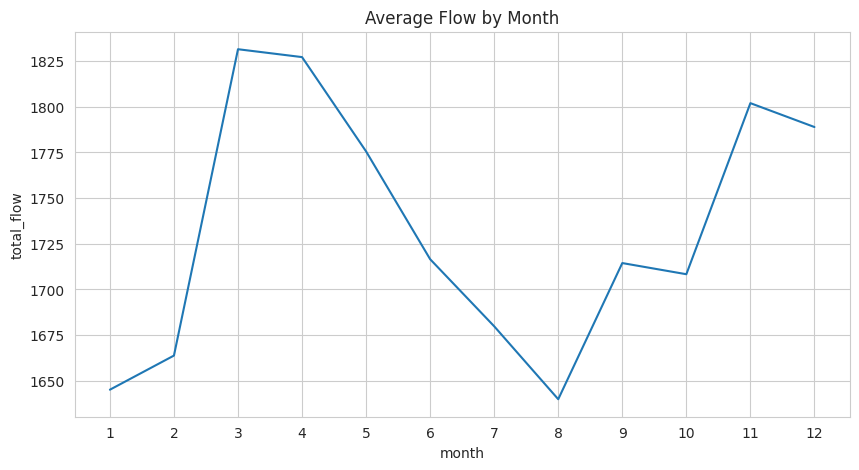

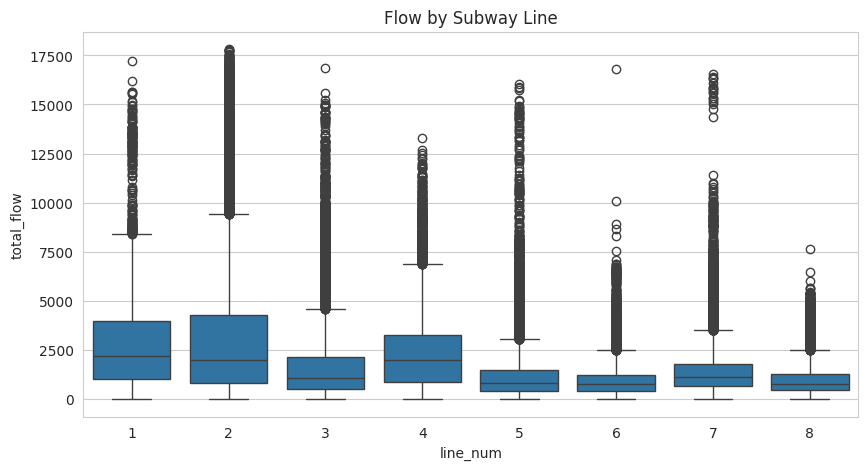

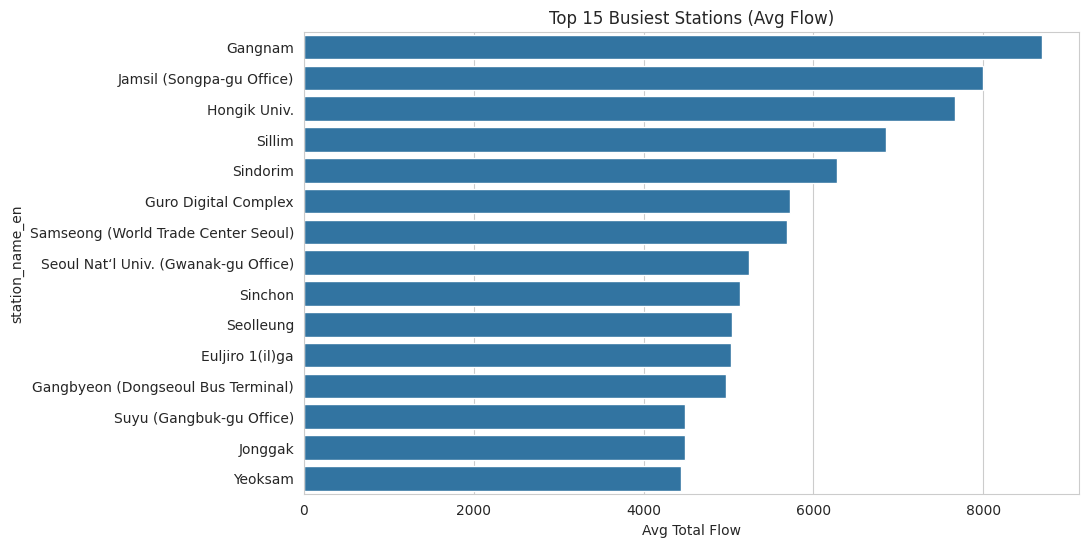

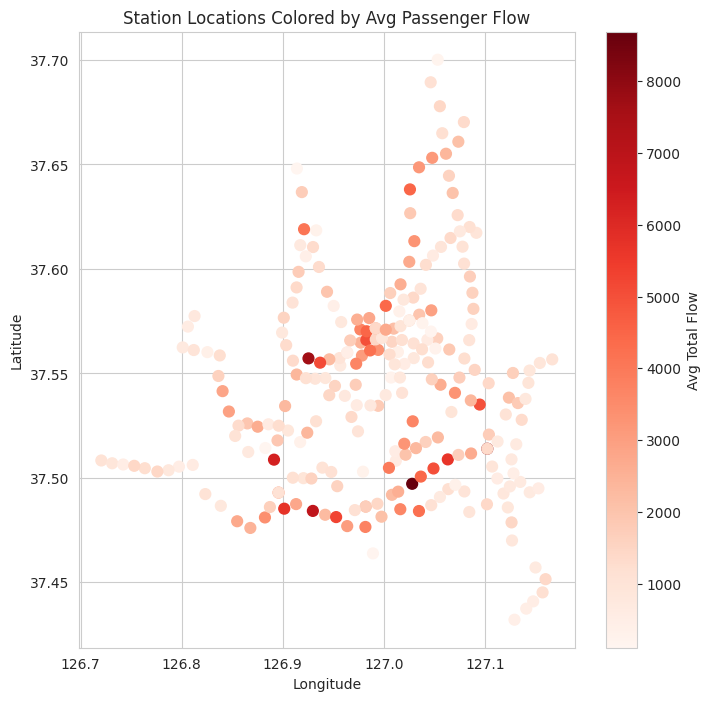

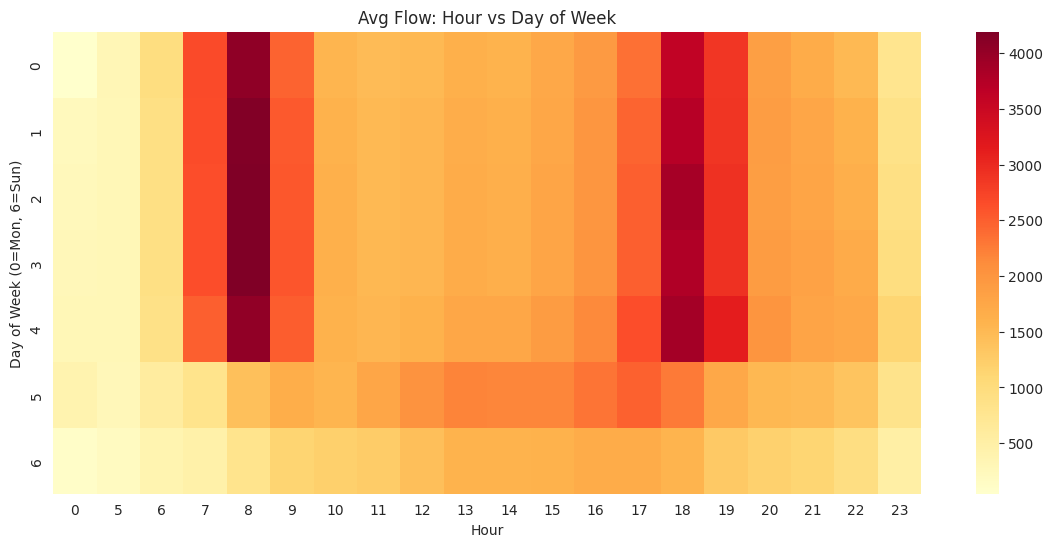

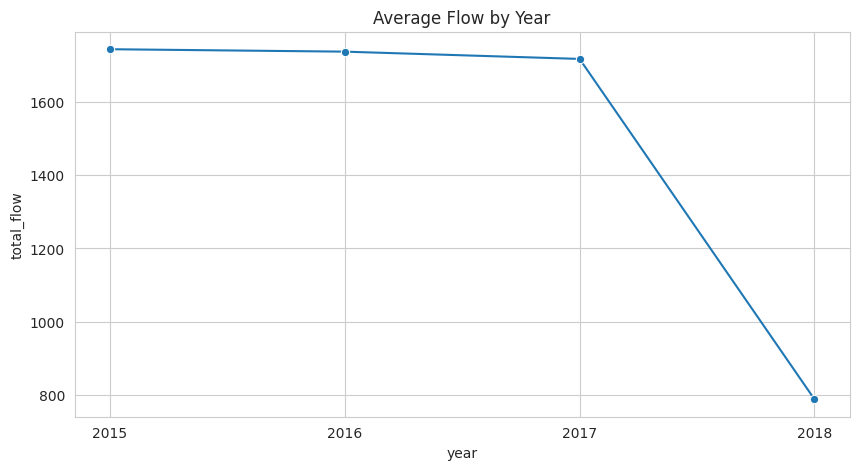

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

# sample for the boxplot cells only (fast, avoids KeyboardInterrupt on 6M rows)
df_sample = df.sample(n=200_000, random_state=42)

# ---------------- 5. Weekend vs weekday ----------------
plt.figure(figsize=(6,5))
sns.boxplot(data=df_sample, x="is_weekend", y="total_flow")
plt.xticks([0,1], ["Weekday", "Weekend"])
plt.title("Weekday vs Weekend Flow")
plt.show()

# ---------------- 6. Morning peak vs evening peak vs off-peak ----------------
df["peak_type"] = "off_peak"
df.loc[df["is_morning_peak"]==1, "peak_type"] = "morning_peak"
df.loc[df["is_evening_peak"]==1, "peak_type"] = "evening_peak"
df_sample["peak_type"] = df.loc[df_sample.index, "peak_type"]

plt.figure(figsize=(8,5))
sns.boxplot(data=df_sample, x="peak_type", y="total_flow")
plt.title("Flow: Morning Peak vs Evening Peak vs Off-Peak")
plt.show()

# ---------------- 7. Month vs total_flow (seasonality) ----------------
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="month", y="total_flow", estimator="mean", errorbar=None)
plt.title("Average Flow by Month")
plt.xticks(range(1,13))
plt.show()

# ---------------- 8. Line number vs total_flow ----------------
plt.figure(figsize=(10,5))
sns.boxplot(data=df_sample, x="line_num", y="total_flow")
plt.title("Flow by Subway Line")
plt.show()

# ---------------- 9. Top 15 busiest stations ----------------
top_stations = (df.groupby("station_name_en")["total_flow"]
                 .mean().sort_values(ascending=False).head(15))

plt.figure(figsize=(10,6))
sns.barplot(x=top_stations.values, y=top_stations.index)
plt.title("Top 15 Busiest Stations (Avg Flow)")
plt.xlabel("Avg Total Flow")
plt.show()

# ---------------- 10. Geographic scatter — lat/long colored by flow intensity ----------------
plt.figure(figsize=(8,8))
station_avg = df.groupby(["station_name_en","latitude","longitude"])["total_flow"].mean().reset_index()
sc = plt.scatter(station_avg["longitude"], station_avg["latitude"],
                  c=station_avg["total_flow"], cmap="Reds", s=60)
plt.colorbar(sc, label="Avg Total Flow")
plt.title("Station Locations Colored by Avg Passenger Flow")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# ---------------- 11. Hour vs Day-of-week heatmap (interaction effect) ----------------
pivot = df.pivot_table(values="total_flow", index="day_of_week", columns="hour", aggfunc="mean")

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Avg Flow: Hour vs Day of Week")
plt.xlabel("Hour")
plt.ylabel("Day of Week (0=Mon, 6=Sun)")
plt.show()

# ---------------- 12. Year-over-year trend (multiple years) ----------------
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="year", y="total_flow", estimator="mean", errorbar=None, marker="o")
plt.title("Average Flow by Year")
plt.xticks(df["year"].unique())
plt.show()

Training until validation scores don't improve for 30 rounds
[50]	valid_0's l1: 538.339
[100]	valid_0's l1: 394.324
[150]	valid_0's l1: 340.519
[200]	valid_0's l1: 312.219
[250]	valid_0's l1: 292.751
[300]	valid_0's l1: 277.401
[350]	valid_0's l1: 266.819
[400]	valid_0's l1: 257.582
[450]	valid_0's l1: 248.193
[500]	valid_0's l1: 241.545
Did not meet early stopping. Best iteration is:
[500]	valid_0's l1: 241.545
MAE:  241.55
RMSE: 474.44
R2:   0.9423

Feature importance:
 hour               7515
station_code       6661
latitude           5798
longitude          4436
day_of_week        3673
month              1209
is_morning_peak     869
is_evening_peak     727
year                558
is_weekend           28
line_num             26
dtype: int32


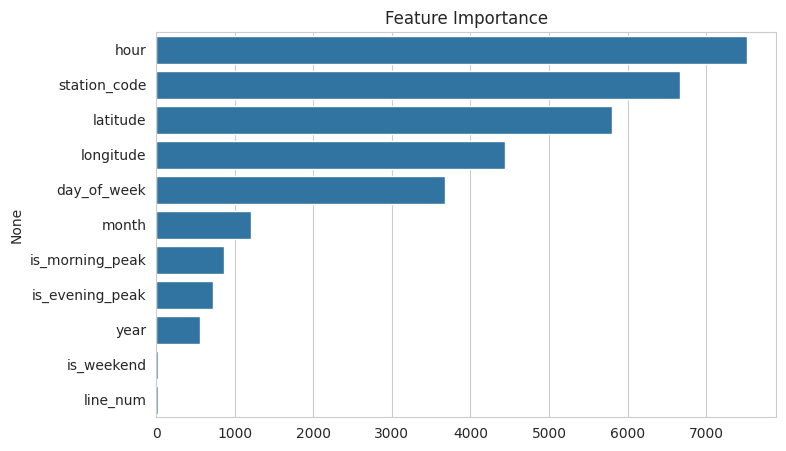

In [16]:
# ============================================================
# MetroFlow — Model Training (LightGBM)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import joblib

# ---------------- 1. FEATURES / TARGET ----------------
feature_cols = [
    "station_code", "line_num", "year", "hour", "day_of_week", "is_weekend",
    "month", "is_morning_peak", "is_evening_peak", "latitude", "longitude",
]
X = df[feature_cols]
y = df["total_flow"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- 2. TRAIN LIGHTGBM ----------------
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

params = {
    "objective": "regression",
    "metric": "mae",
    "learning_rate": 0.05,
    "num_leaves": 64,
    "max_depth": -1,
    "verbose": -1,
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(50)],
)

# ---------------- 3. EVALUATE ----------------
preds = model.predict(X_test, num_iteration=model.best_iteration)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.4f}")

# ---------------- 4. FEATURE IMPORTANCE ----------------
importance = pd.Series(model.feature_importance(), index=feature_cols).sort_values(ascending=False)
print("\nFeature importance:\n", importance)

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.barplot(x=importance.values, y=importance.index)
plt.title("Feature Importance")
plt.show()

# ---------------- 5. SAVE MODEL ----------------
 

In [30]:
model.save_model("/kaggle/working/crowd_prediction_lgbm.txt")
joblib.dump(feature_cols, "/kaggle/working/feature_cols.pkl")
print("\nModel saved to /kaggle/working/crowd_prediction_lgbm.txt")


Model saved to /kaggle/working/crowd_prediction_lgbm.txt


In [26]:
# ============================================================
# MetroFlow — Test Your Trained LightGBM Model (in-memory) on Samples
# ============================================================

import pandas as pd

# ---------------- PICK 5 RANDOM SAMPLES FROM YOUR TEST SET ----------------
sample = X_test.sample(5, random_state=1)
actual = y_test.loc[sample.index]

preds = model.predict(sample, num_iteration=model.best_iteration)

results = sample.copy()
results["actual_flow"] = actual.values
results["predicted_flow"] = preds.round(0)
results["error"] = (results["actual_flow"] - results["predicted_flow"]).abs()

print(results[["station_code", "hour", "day_of_week", "actual_flow", "predicted_flow", "error"]])

         station_code  hour  day_of_week  actual_flow  predicted_flow   error
1864028           317    18            6         1780          2965.0  1185.0
2082663           203     7            4         2968          2110.0   858.0
4981061          2542     8            6          292           223.0    69.0
3359217           413    13            5         3452          3281.0   171.0
5367630          2751     6            6          250           204.0    46.0


Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 259.683
[200]	valid_0's l1: 205.406
[300]	valid_0's l1: 189.749
[400]	valid_0's l1: 181.577
[500]	valid_0's l1: 177.503
[600]	valid_0's l1: 174.546
[700]	valid_0's l1: 171.902
[800]	valid_0's l1: 170.126
[900]	valid_0's l1: 168.59
[1000]	valid_0's l1: 167.188
[1100]	valid_0's l1: 165.99
[1200]	valid_0's l1: 165.033
[1300]	valid_0's l1: 164.305
[1400]	valid_0's l1: 163.461
[1500]	valid_0's l1: 162.847
[1600]	valid_0's l1: 162.238
[1700]	valid_0's l1: 161.813
[1800]	valid_0's l1: 161.527
[1900]	valid_0's l1: 160.609
[2000]	valid_0's l1: 160.195
Did not meet early stopping. Best iteration is:
[1997]	valid_0's l1: 160.193
MAE:  160.19
RMSE: 399.82
R2:   0.9590

Feature importance:
 month                   36162
hour_day_interaction    34120
station_code            31414
day_of_week             30027
latitude                26332
station_hour_avg        26113
longitude               21613
hour                  

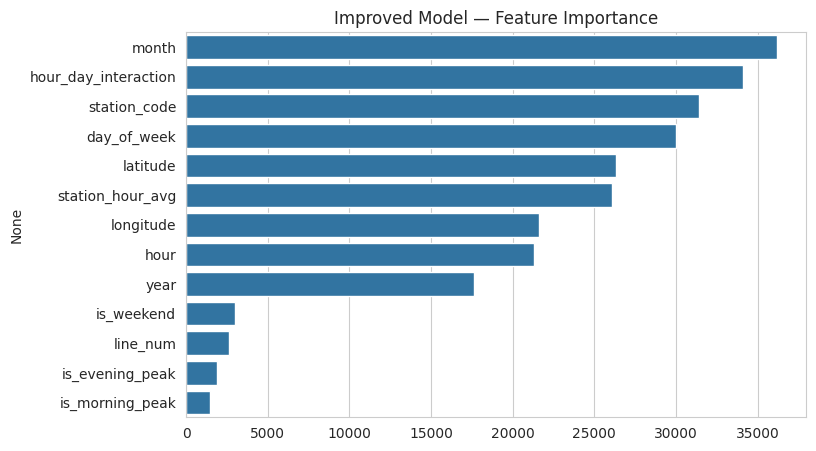


Sample predictions:
         station_code  hour  day_of_week  actual_flow  predicted_flow  error
1864028           317    18            6         1780          2276.0  496.0
2082663           203     7            4         2968          2480.0  488.0
4981061          2542     8            6          292           331.0   39.0
3359217           413    13            5         3452          3287.0  165.0
5367630          2751     6            6          250           283.0   33.0


In [27]:
# ============================================================
# MetroFlow — Improved LightGBM Model
# Adds: hour x day_of_week interaction + station-hour historical average
# (leakage-safe: station_hour_avg computed on TRAIN only, mapped onto TEST)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- 1. BASE FEATURES ----------------
base_feature_cols = [
    "station_code", "line_num", "year", "hour", "day_of_week", "is_weekend",
    "month", "is_morning_peak", "is_evening_peak", "latitude", "longitude",
]

# ---------------- 2. NEW FEATURE: hour x day_of_week interaction ----------------
df["hour_day_interaction"] = (
    df["hour"].astype(str) + "_" + df["day_of_week"].astype(str)
).astype("category").cat.codes

# ---------------- 3. TRAIN/TEST SPLIT (do this BEFORE computing station_hour_avg) ----------------
feature_cols = base_feature_cols + ["hour_day_interaction", "station_hour_avg"]

X = df.drop(columns=["total_flow"])
y = df["total_flow"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- 4. NEW FEATURE: station-hour historical average (leakage-safe) ----------------
# compute ONLY on training data
station_hour_avg_train = (
    X_train.assign(total_flow=y_train)
    .groupby(["station_code", "hour"])["total_flow"]
    .mean()
)

# global fallback for station/hour combos not seen in training
global_avg = y_train.mean()

X_train["station_hour_avg"] = (
    X_train.set_index(["station_code", "hour"]).index.map(station_hour_avg_train).values
)
X_test["station_hour_avg"] = (
    X_test.set_index(["station_code", "hour"]).index.map(station_hour_avg_train).values
)

# fill any missing (station/hour combos unseen in training) with global average
X_train["station_hour_avg"] = X_train["station_hour_avg"].fillna(global_avg)
X_test["station_hour_avg"] = X_test["station_hour_avg"].fillna(global_avg)

# ---------------- 5. FINAL FEATURE MATRICES ----------------
X_train_final = X_train[feature_cols]
X_test_final = X_test[feature_cols]

# ---------------- 6. TRAIN LIGHTGBM ----------------
train_data = lgb.Dataset(X_train_final, label=y_train)
test_data = lgb.Dataset(X_test_final, label=y_test, reference=train_data)

params = {
    "objective": "regression",
    "metric": "mae",
    "learning_rate": 0.03,
    "num_leaves": 128,
    "min_data_in_leaf": 20,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1,
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)],
)

# ---------------- 7. EVALUATE ----------------
preds = model.predict(X_test_final, num_iteration=model.best_iteration)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.4f}")

# ---------------- 8. FEATURE IMPORTANCE ----------------
importance = pd.Series(model.feature_importance(), index=feature_cols).sort_values(ascending=False)
print("\nFeature importance:\n", importance)

plt.figure(figsize=(8,5))
sns.barplot(x=importance.values, y=importance.index)
plt.title("Improved Model — Feature Importance")
plt.show()

# ---------------- 9. SAVE MODEL ----------------
 

# ---------------- 10. QUICK SAMPLE CHECK ----------------
sample = X_test_final.sample(5, random_state=1)
actual = y_test.loc[sample.index]
sample_preds = model.predict(sample, num_iteration=model.best_iteration)

results = sample.copy()
results["actual_flow"] = actual.values
results["predicted_flow"] = sample_preds.round(0)
results["error"] = (results["actual_flow"] - results["predicted_flow"]).abs()
print("\nSample predictions:")
print(results[["station_code", "hour", "day_of_week", "actual_flow", "predicted_flow", "error"]])

In [29]:
model.save_model("/kaggle/working/crowd_prediction_lgbm_v2.txt")
print("\nModel saved to /kaggle/working/crowd_prediction_lgbm_v2.txt")


Model saved to /kaggle/working/crowd_prediction_lgbm_v2.txt


In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

MAE:  172.77
RMSE: 432.90
R2:   0.9519

Feature importance:
 station_code       0.359454
hour               0.232833
latitude           0.163494
longitude          0.120849
day_of_week        0.052063
is_weekend         0.026257
is_evening_peak    0.025031
is_morning_peak    0.008163
month              0.007984
year               0.003083
line_num           0.000788
dtype: float64


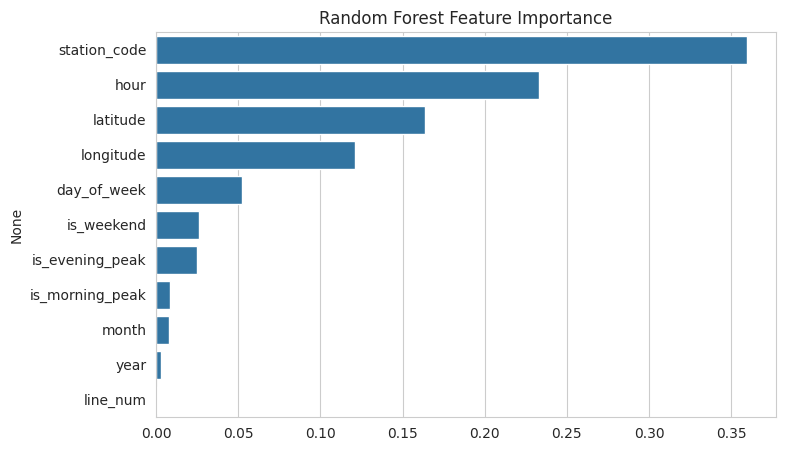

In [32]:
# ============================================================
# MetroFlow — Model Training (Random Forest)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# ---------------- 1. FEATURES / TARGET ----------------
feature_cols = [
    "station_code", "line_num", "year", "hour", "day_of_week", "is_weekend",
    "month", "is_morning_peak", "is_evening_peak", "latitude", "longitude",
]
X = df[feature_cols]
y = df["total_flow"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- 2. TRAIN RANDOM FOREST ----------------
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,          # use all CPU cores
    random_state=42,
)

rf_model.fit(X_train, y_train)

# ---------------- 3. EVALUATE ----------------
preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, preds))
rf_r2 = r2_score(y_test, preds)

print(f"MAE:  {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R2:   {rf_r2:.4f}")

# ---------------- 4. FEATURE IMPORTANCE ----------------
importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importance:\n", importance)

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.barplot(x=importance.values, y=importance.index)
plt.title("Random Forest Feature Importance")
plt.show()


In [35]:
sample = X_test.sample(5, random_state=1)
actual = y_test.loc[sample.index]
sample_preds = rf_model.predict(sample)

results = sample.copy()
results["actual_flow"] = actual.values
results["predicted_flow"] = sample_preds.round(0)
results["error"] = (results["actual_flow"] - results["predicted_flow"]).abs()

print("\nRandom Forest sample predictions:")
print(results[["station_code", "hour", "day_of_week", "actual_flow", "predicted_flow", "error"]])


Random Forest sample predictions:
         station_code  hour  day_of_week  actual_flow  predicted_flow  error
1864028           317    18            6         1780          2046.0  266.0
2082663           203     7            4         2968          2592.0  376.0
4981061          2542     8            6          292           355.0   63.0
3359217           413    13            5         3452          3209.0  243.0
5367630          2751     6            6          250           235.0   15.0


In [36]:
import joblib

joblib.dump(rf_model, "/kaggle/working/crowd_prediction_rf.pkl")
print("Model saved to /kaggle/working/crowd_prediction_rf.pkl")

Model saved to /kaggle/working/crowd_prediction_rf.pkl


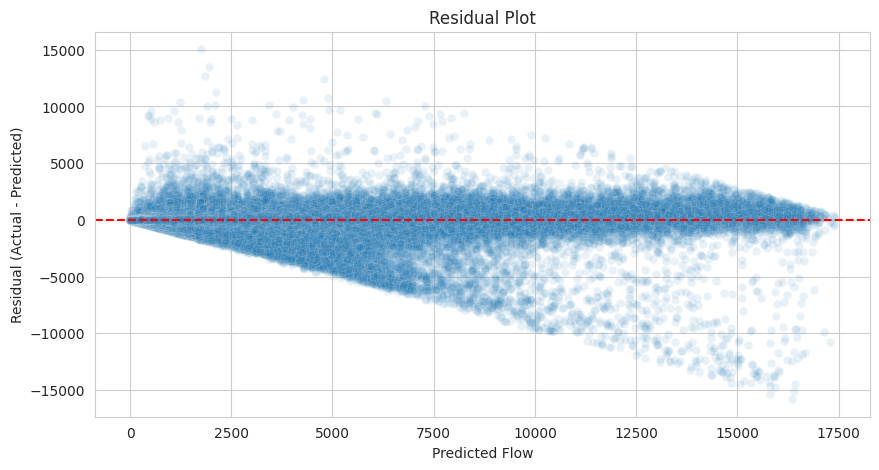

In [37]:
residuals = y_test.values - rf_model.predict(X_test)

plt.figure(figsize=(10,5))
sns.scatterplot(x=rf_model.predict(X_test), y=residuals, alpha=0.1)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Flow")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

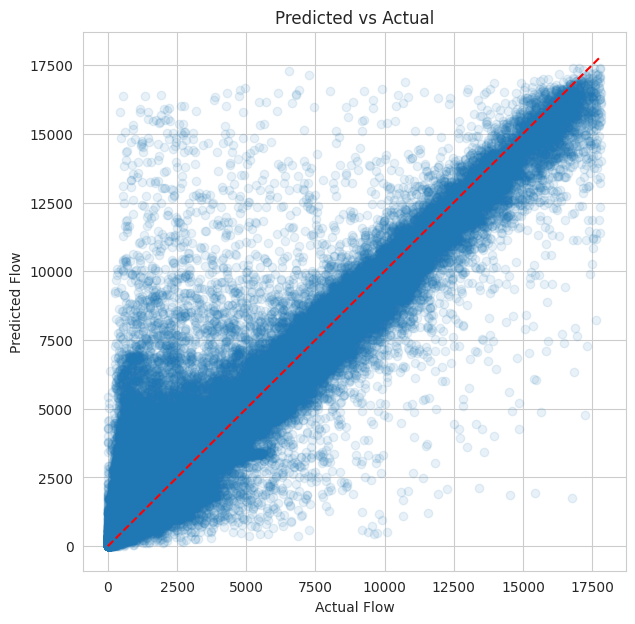

In [38]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, rf_model.predict(X_test), alpha=0.1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Flow")
plt.ylabel("Predicted Flow")
plt.title("Predicted vs Actual")
plt.show()

In [39]:
error_df = X_test.copy()
error_df["actual"] = y_test.values
error_df["predicted"] = rf_model.predict(X_test)
error_df["abs_error"] = (error_df["actual"] - error_df["predicted"]).abs()

worst_stations = error_df.groupby("station_code")["abs_error"].mean().sort_values(ascending=False).head(10)
print("Hardest stations to predict:\n", worst_stations)

Hardest stations to predict:
 station_code
222    745.562099
216    614.322057
219    606.742800
239    591.494436
220    505.938484
221    496.821105
218    479.999059
234    468.387928
230    447.140204
232    435.229636
Name: abs_error, dtype: float64


In [41]:
comparison = pd.DataFrame({
    "Model": ["LightGBM", "Random Forest"],
    "MAE": [241.55, 172.77],
    "RMSE": [474.44, 432.90],
    "R2": [0.9423, 0.9519],
})
print(comparison)

           Model     MAE    RMSE      R2
0       LightGBM  241.55  474.44  0.9423
1  Random Forest  172.77  432.90  0.9519
